In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [8]:
workspace = '/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE'

In [9]:
# Custom loader function for .npy files
def mat_loader(path):
    """Load .npy file and convert to tensor"""
    image = sio.loadmat(path)['complex_img']  # Assuming the .mat file has a 'data' variable
    
    image = torch.from_numpy(image)

    # Add channel dimension but keep as numpy
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)

    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image  # (H, W) -> (3, H, W)

# Before Pre-processing

## Raw mat files

In [10]:
synth_ds = datasets.DatasetFolder(
    os.path.join(workspace, "mat_files/synth"),
    extensions = (".mat"),
    loader = mat_loader,
)
meas_ds = datasets.DatasetFolder(
    os.path.join(workspace, "mat_files/real"),
    extensions = (".mat"),
    loader = mat_loader,
)

In [11]:
synth_vals = []

for i in range(len(synth_ds)):
    synth_img = torch.abs(synth_ds[i][0][0])
    u, sigma = synth_img.mean(), synth_img.var()
    synth_vals.append((u.item(), sigma.item()))

meas_vals = []

for i in range(len(meas_ds)):
    meas_img = torch.abs(meas_ds[i][0][0])
    u, sigma = meas_img.mean(), meas_img.var()
    meas_vals.append((u.item(), sigma.item()))

In [12]:
np.array(synth_vals)[:, 0].min(), np.array(synth_vals)[:, 0].max(), np.array(synth_vals)[:, 1].min(), np.array(synth_vals)[:, 1].max()

(np.float64(0.011417248603680699),
 np.float64(0.046856048685298766),
 np.float64(0.0003537402054109107),
 np.float64(0.7251804811761491))

In [13]:
np.array(meas_vals)[:, 0].min(), np.array(meas_vals)[:, 0].max(), np.array(meas_vals)[:, 1].min(), np.array(meas_vals)[:, 1].max()

(np.float64(0.029281900719851706),
 np.float64(0.07666608975696576),
 np.float64(0.0009131493637416228),
 np.float64(0.46025447268691894))

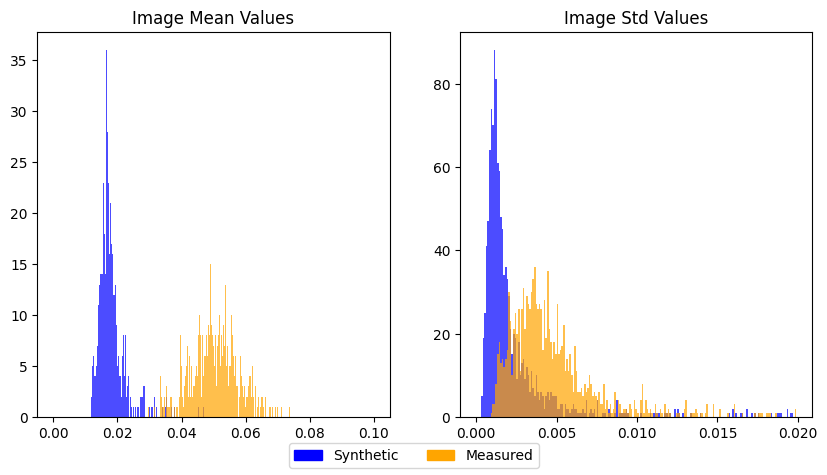

In [14]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in synth_vals], bins = np.arange(0, 0.1, 0.0001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in meas_vals], bins = np.arange(0, 0.1, 0.0001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_title("Image Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in synth_vals], bins = np.arange(0, 0.02, 0.0001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in meas_vals], bins = np.arange(0, 0.02, 0.0001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_title("Image Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

## decibel

In [15]:
decibel_synth_ds = datasets.ImageFolder(
    os.path.join(workspace, "png_images/decibel/synth"),
    transform = transforms.ToTensor()
)
decibel_meas_ds = datasets.ImageFolder(
    os.path.join(workspace, "png_images/decibel/real"),
    transform = transforms.ToTensor()
)

In [16]:
decibel_synth_vals = []

for i in range(len(decibel_synth_ds)):
    synth_img = torch.abs(decibel_synth_ds[i][0][0])
    u, sigma = synth_img.mean(), synth_img.var()
    decibel_synth_vals.append((u.item(), sigma.item()))

decibel_meas_vals = []

for i in range(len(decibel_meas_ds)):
    meas_img = torch.abs(decibel_meas_ds[i][0][0])
    u, sigma = meas_img.mean(), meas_img.var()
    decibel_meas_vals.append((u.item(), sigma.item()))

In [17]:
np.array(decibel_synth_vals)[:, 0].min(), np.array(decibel_synth_vals)[:, 0].max(), np.array(decibel_synth_vals)[:, 1].min(), np.array(decibel_synth_vals)[:, 1].max()

(np.float64(0.3598369359970093),
 np.float64(0.6168217658996582),
 np.float64(0.011654892936348915),
 np.float64(0.01884431764483452))

In [18]:
np.array(decibel_meas_vals)[:, 0].min(), np.array(decibel_meas_vals)[:, 0].max(), np.array(decibel_meas_vals)[:, 1].min(), np.array(decibel_meas_vals)[:, 1].max()

(np.float64(0.4568113088607788),
 np.float64(0.729038417339325),
 np.float64(0.00985962525010109),
 np.float64(0.01449132151901722))

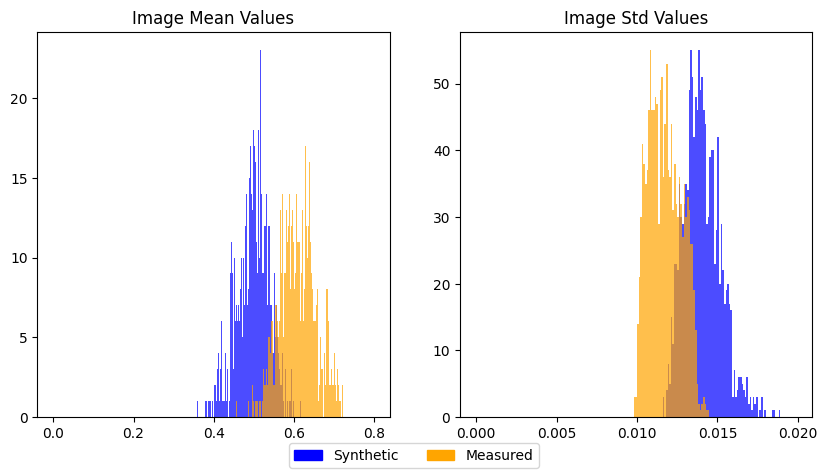

In [19]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in decibel_synth_vals], bins = np.arange(0, 0.8, 0.001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in decibel_meas_vals], bins = np.arange(0, 0.8, 0.001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_title("Image Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in decibel_synth_vals], bins = np.arange(0, 0.02, 0.0001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in decibel_meas_vals], bins = np.arange(0, 0.02, 0.0001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_title("Image Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

## qpm

In [20]:
qpm_synth_ds = datasets.ImageFolder(
    os.path.join(workspace, "png_images/qpm/synth"),
    transform = transforms.ToTensor()
)
qpm_meas_ds = datasets.ImageFolder(
    os.path.join(workspace, "png_images/qpm/real"),
    transform = transforms.ToTensor()
)

In [21]:
qpm_synth_vals = []

for i in range(len(qpm_synth_ds)):
    synth_img = torch.abs(qpm_synth_ds[i][0][0])
    u, sigma = synth_img.mean(), synth_img.var()
    qpm_synth_vals.append((u.item(), sigma.item()))

qpm_meas_vals = []

for i in range(len(qpm_meas_ds)):
    meas_img = torch.abs(qpm_meas_ds[i][0][0])
    u, sigma = meas_img.mean(), meas_img.var()
    qpm_meas_vals.append((u.item(), sigma.item()))

In [22]:
np.array(qpm_synth_vals)[:, 0].min(), np.array(qpm_synth_vals)[:, 0].max(), np.array(qpm_synth_vals)[:, 1].min(), np.array(qpm_synth_vals)[:, 1].max()

(np.float64(0.10369729995727539),
 np.float64(0.26175057888031006),
 np.float64(0.005867748986929655),
 np.float64(0.01200578548014164))

In [23]:
np.array(qpm_meas_vals)[:, 0].min(), np.array(qpm_meas_vals)[:, 0].max(), np.array(qpm_meas_vals)[:, 1].min(), np.array(qpm_meas_vals)[:, 1].max()

(np.float64(0.14759834110736847),
 np.float64(0.39146825671195984),
 np.float64(0.007593323010951281),
 np.float64(0.01759624108672142))

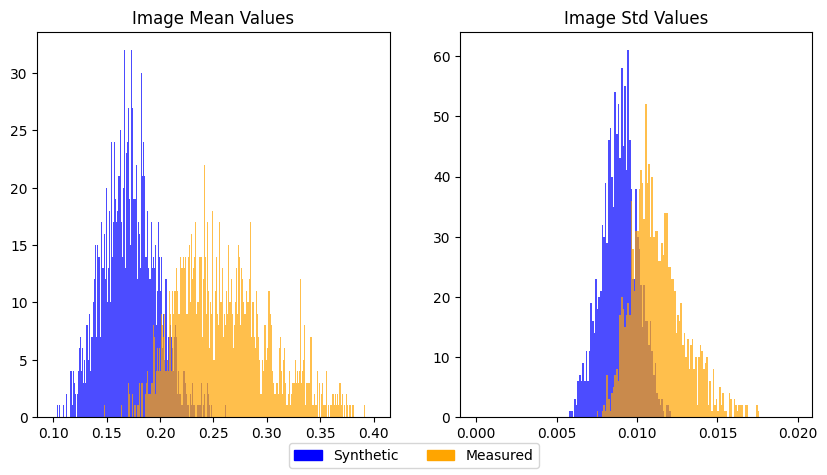

In [24]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in qpm_synth_vals], bins = np.arange(0.1, 0.4, 0.001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in qpm_meas_vals], bins = np.arange(0.1, 0.4, 0.001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_title("Image Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in qpm_synth_vals], bins = np.arange(0.0, 0.02, 0.0001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in qpm_meas_vals], bins = np.arange(0.0, 0.02, 0.0001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_title("Image Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

# After Processing

In [2]:
def npy_loader(path):
    """Load .npy file and convert to tensor"""
    image = np.load(path).astype(np.float32)
    
    image = torch.from_numpy(image)

    # Add channel dimension but keep as numpy
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)

    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image  # (H, W) -> (3, H, W)

log_synth_ds = datasets.DatasetFolder(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/synth",
    extensions = (".npy"),
    loader = npy_loader,
)
log_meas_ds = datasets.DatasetFolder(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/real",
    extensions = (".npy"),
    loader = npy_loader,
)

In [3]:
log_synth_vals = []

for i in range(len(log_synth_ds)):
    u, sigma = log_synth_ds[i][0][0].mean(), log_synth_ds[i][0][0].std()
    log_synth_vals.append((u.item(), sigma.item()))

log_meas_vals = []

for i in range(len(log_meas_ds)):
    u, sigma = log_meas_ds[i][0][0].mean(), log_meas_ds[i][0][0].std()
    log_meas_vals.append((u.item(), sigma.item()))

In [4]:
np.array(log_synth_vals)[:, 0].min(), np.array(log_synth_vals)[:, 0].max(), np.array(log_synth_vals)[:, 1].min(), np.array(log_synth_vals)[:, 1].max()

(np.float64(0.03742241486907005),
 np.float64(0.5150927305221558),
 np.float64(0.050990499556064606),
 np.float64(0.12626254558563232))

In [5]:
np.array(log_meas_vals)[:, 0].min(), np.array(log_meas_vals)[:, 0].max(), np.array(log_meas_vals)[:, 1].min(), np.array(log_meas_vals)[:, 1].max()

(np.float64(0.10367362201213837),
 np.float64(0.6377480030059814),
 np.float64(0.058100372552871704),
 np.float64(0.11521340906620026))

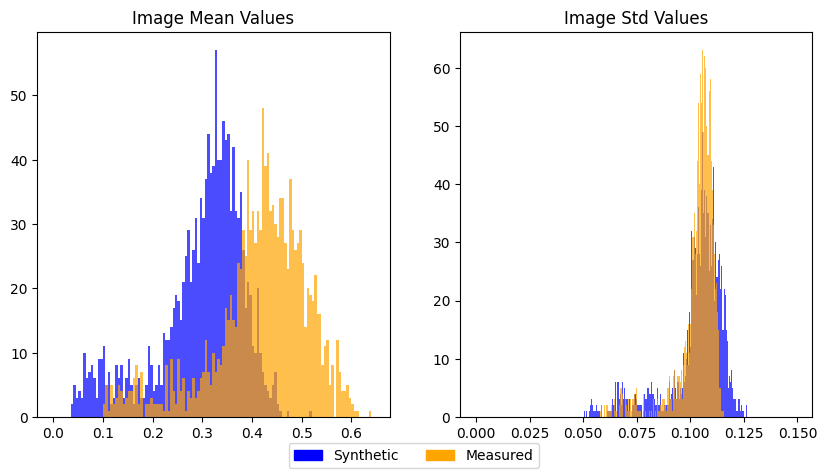

In [7]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in log_synth_vals], bins = np.arange(0, 0.65, 0.005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in log_meas_vals], bins = np.arange(0, 0.65, 0.005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_title("Image Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in log_synth_vals], bins = np.arange(0, 0.15, 0.0005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in log_meas_vals], bins = np.arange(0, 0.15, 0.0005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_title("Image Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

In [1]:
path = "/workspace/alvin/SAR_ML/data/SAMPLE/mat_files/synth/m1"

In [7]:
ds0 = sorted(os.listdir(path))[0]

In [12]:
sio.loadmat(os.path.join(path, ds0))["complex_img"]

array([[ 1.83653616e-03+2.42058121e-03j,  1.93712143e-04+4.90114357e-03j,
        -2.35022907e-03+5.65001731e-03j, ...,
        -7.31137359e-05-3.72640790e-03j,  4.83359343e-04-4.57298585e-03j,
         1.02717892e-05-3.92485713e-03j],
       [ 1.08740886e-04-2.59604032e-04j,  6.50268261e-05+3.86248149e-03j,
        -2.33869698e-03+6.81263687e-03j, ...,
         1.73368815e-03+1.18917946e-03j,  2.09513674e-03+1.62042125e-03j,
        -1.08093222e-03+3.61796507e-04j],
       [-1.71013479e-03+5.71474719e-04j,  6.91535518e-04+3.10514607e-03j,
         5.21732521e-04+6.23220426e-03j, ...,
        -9.15168219e-05+2.52991120e-03j, -6.49950168e-04+2.04070958e-03j,
        -1.39820952e-03+1.32016985e-03j],
       ...,
       [-8.56144449e-04-8.49605009e-04j, -1.06645160e-03-2.68570727e-04j,
         2.16441878e-04+1.21392491e-03j, ...,
        -1.89547711e-03+3.17410209e-03j, -4.47580611e-04+2.08898369e-03j,
        -1.28092304e-04+8.56973671e-04j],
       [ 1.46071291e-03-2.30292052e-03j,  2.